<a href="https://colab.research.google.com/github/cdiegor/OtimizacaoCombinatoria/blob/main/VRP_BC_BP_Pyomo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# VRP — Branch-and-Cut (min-cut) e Branch-and-Price (Pyomo, CBC)



In [3]:
!pip install pyomo networkx gurobipy
!apt-get install -y -qq glpk-utils
!apt-get install -y -qq coinor-cbc

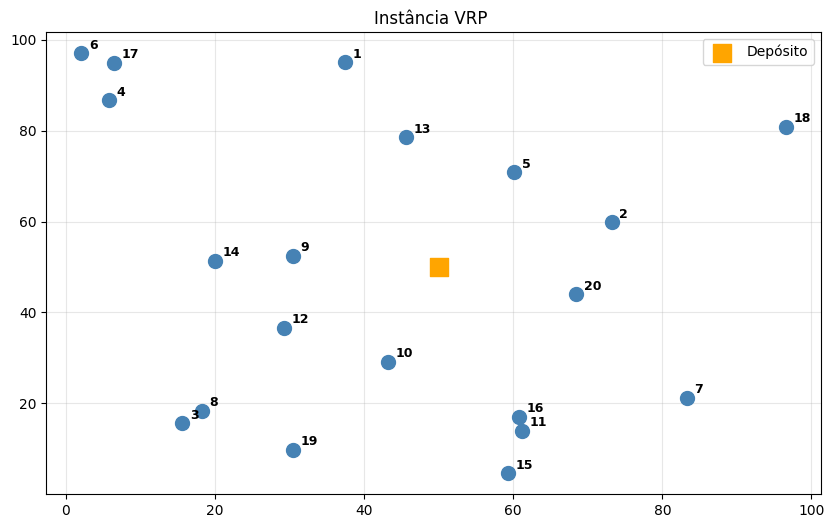

In [4]:
import math, time, random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict, deque
from heapq import heappush, heappop

# Tenta importar Pyomo
try:
    import pyomo.environ as pyo
except ImportError:
    print("Pyomo não instalado.")

# Configuração Visual
plt.rcParams["figure.figsize"] = (10, 6)

@dataclass
class VRPInstance:
    n: int         # Clientes
    K: int         # Veículos
    Q: int         # Capacidade do Veículo
    coords: np.ndarray
    dist: np.ndarray

def make_instance(n=20, K=4, Q=6, seed=42):
    np.random.seed(seed)
    depot = np.array([[50.0, 50.0]]) # Centro
    # Clientes espalhados
    clients = np.random.uniform(0, 100, size=(n, 2))
    coords = np.vstack([depot, clients])

    diff = coords[:,None,:] - coords[None,:,:]
    dist = np.sqrt(np.sum(diff**2, axis=2))

    return VRPInstance(n=n, K=K, Q=Q, coords=coords, dist=dist)

def plot_routes(inst, routes, title="Rotas"):
    plt.figure()
    # Plota arestas das rotas
    colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))

    for idx, r in enumerate(routes):
        r_coords = inst.coords[r]
        # Adiciona o retorno ao zero se não tiver
        if r[-1] != 0:
            r_coords = np.vstack([r_coords, inst.coords[0]])

        plt.plot(r_coords[:,0], r_coords[:,1], c=colors[idx], linewidth=2, label=f"V{idx+1}", zorder=1)
        # Setas
        mid_idx = len(r)//2
        plt.arrow(r_coords[mid_idx,0], r_coords[mid_idx,1],
                  (r_coords[mid_idx+1,0]-r_coords[mid_idx,0])*0.01,
                  (r_coords[mid_idx+1,1]-r_coords[mid_idx,1])*0.01,
                  color=colors[idx], head_width=2)

    # Plota nós
    plt.scatter(inst.coords[1:,0], inst.coords[1:,1], c='steelblue', s=100, zorder=2)
    plt.scatter(inst.coords[0,0], inst.coords[0,1], c='orange', marker='s', s=150, zorder=3, label="Depósito")

    for i in range(1, inst.n+1):
        plt.text(inst.coords[i,0]+1, inst.coords[i,1]+1, str(i), fontsize=9, fontweight='bold')

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def get_solver(max_seconds=300):
    # Prioriza CBC, fallback GLPK
    opt = pyo.SolverFactory('gurobi')
    if opt.available():
        opt.options['TimeLimit'] = max_seconds
        return 'gurobi', opt
    opt = pyo.SolverFactory('cbc')
    if opt.available():
        opt.options['seconds'] = max_seconds
        return 'cbc', opt
    opt = pyo.SolverFactory('glpk')
    if opt.available():
        opt.options['tmlim'] = max_seconds
        return 'glpk', opt
    return None, None

# --- CRIAÇÃO DA INSTÂNCIA ---
# Capacidade Q=5 força os 3-4 veículos a trabalharem duro
inst = make_instance(n=20, K=4, Q=7, seed=42)
plot_routes(inst, [], "Instância VRP ")

## Instâncias e visualização


## Parte I — Branch-and-Cut com **out-cuts** via **min-cut**

Modelo base (m-TSP por arcos; graus em clientes = 1; $K$ saídas/entradas no depósito).  
Os **out-cuts** $\sum_{i\in S}\sum_{j\notin S} x_{ij} \ge 1$ são separados resolvendo **min-cut** $(0\to t)$ para cada cliente $t$.  
Agora com **deduplicação de cortes**, **tolerâncias** e opção de **laço em LP**.


Modelo Matemático: Branch-and-Cut (2-Index Flow)Seja $G = (V, A)$ um grafo onde $V = \{0, ..., n\}$ é o conjunto de nós (0 é o depósito) e $A$ o conjunto de arcos.

Variáveis de Decisão:$$x_{ij} = \begin{cases} 1 & \text{se o veículo viaja do nó } i \text{ para } j \\ 0 & \text{caso contrário} \end{cases}$$

Função Objetivo:Minimizar o custo total de transporte:

$$\min \sum_{i \in V} \sum_{j \in V, i \neq j} c_{ij} x_{ij}$$

Restrições:

Grau de Entrada e Saída: Cada cliente deve ser visitado exatamente uma vez.$$\sum_{j \in V, j \neq i} x_{ij} = 1 \quad \forall i \in V \setminus \{0\}$$

$$\sum_{i \in V, i \neq j} x_{ij} = 1 \quad \forall j \in V \setminus \{0\}$$

Fluxo no Depósito: O número de veículos saindo e voltando ao depósito deve ser igual a $K$ (número de veículos).

$$\sum_{j \in V \setminus \{0\}} x_{0j} = K$$

$$\sum_{i \in V \setminus \{0\}} x_{i0} = K$$

Eliminação de Subciclos (Capacity Cuts): Para qualquer subconjunto de clientes $S \subseteq V \setminus \{0\}$, a frota deve ser suficiente para atender a demanda.

$$\sum_{i \in S} \sum_{j \in S, j \neq i} x_{ij} \leq |S| - 1$$

 Esta restrição é geralmente adicionada via Callbacks (Cortes).

In [5]:
def extract_routes_from_x(inst, x_val):
    """Reconstrói rotas a partir do dicionário de arcos ativos x[i,j]=1"""
    adj = defaultdict(list)
    for (i,j) in x_val:
        adj[i].append(j)

    routes = []
    if 0 in adj:
        for start in adj[0]:
            route = [0, start]
            curr = start
            while curr != 0:
                if curr not in adj or not adj[curr]: break # rota quebrada
                nxt = adj[curr][0]
                route.append(nxt)
                curr = nxt
                if curr == 0: break
            routes.append(route)
    return routes

def solve_branch_and_cut(inst, max_iters=100, time_limit=300):
    print(f"--- B&C Iniciado (CVRP Q={inst.Q}) ---")
    m = pyo.ConcreteModel()
    N = list(range(inst.n + 1))
    A = [(i,j) for i in N for j in N if i != j]

    m.x = pyo.Var(A, within=pyo.Binary)

    # Minimizar distância
    m.obj = pyo.Objective(expr=sum(inst.dist[i,j] * m.x[i,j] for i,j in A))

    m.cons = pyo.ConstraintList()

    # Grau (Assignment Constraints)
    for i in N:
        if i == 0:
            m.cons.add(sum(m.x[0, j] for j in N if j!=0) == inst.K)
            m.cons.add(sum(m.x[j, 0] for j in N if j!=0) == inst.K)
        else:
            m.cons.add(sum(m.x[i, j] for j in N if j!=i) == 1)
            m.cons.add(sum(m.x[j, i] for j in N if j!=i) == 1)

    m.cuts = pyo.ConstraintList()

    _, solver = get_solver(max_seconds=60) # Solver rápido por iteração
    start_time = time.time()

    for it in range(max_iters):
        res = solver.solve(m, tee=False)

        # Recupera arcos
        x_sol = {(i,j) for i,j in A if pyo.value(m.x[i,j]) > 0.5}

        # Cria grafo para análise
        G = nx.DiGraph()
        G.add_nodes_from(N)
        G.add_edges_from(x_sol)

        # Separação
        new_cuts = 0
        violation = False

        # 1. Subciclos desconectados do depósito
        comps = list(nx.strongly_connected_components(G))
        for comp in comps:
            if 0 not in comp and len(comp) >= 2:
                # Subciclo isolado detectado
                violation = True
                S = list(comp)
                # Corte: x(S:S) <= |S| - 1
                expr = sum(m.x[i,j] for i in S for j in S if (i,j) in A)
                m.cuts.add(expr <= len(S) - 1)
                new_cuts += 1

        # 2. Violação de Capacidade em rotas conectadas ao depósito
        # Reconstrói rotas para checar carga
        current_routes = extract_routes_from_x(inst, x_sol)
        for r in current_routes:
            # r é [0, 1, 5, 0] etc.
            # Demanda = len(r) - 2 (desconta os dois zeros)
            load = len(r) - 2
            if load > inst.Q:
                violation = True
                # Rota excede capacidade. Adicionar corte no conjunto de clientes S
                S = [node for node in r if node != 0]

                # Rounded Capacity Inequality
                # x(S:S) <= |S| - ceil(Demand(S)/Q)
                min_vehicles = math.ceil(load / inst.Q)
                expr = sum(m.x[i,j] for i in S for j in S if (i,j) in A)
                m.cuts.add(expr <= len(S) - min_vehicles)
                new_cuts += 1

        if not violation:
            print(f"B&C It {it}: Ótimo Encontrado! Obj={pyo.value(m.obj):.2f}")
            break

        if it % 1 == 0:
            print(f"B&C It {it}: Obj={pyo.value(m.obj):.2f}, Cortes={new_cuts}")

        if time.time() - start_time > time_limit:
            print("Time Limit.")
            break

    return pyo.value(m.obj), extract_routes_from_x(inst, {(i,j) for i,j in A if pyo.value(m.x[i,j]) > 0.9})


## Parte II — Branch-and-Price (heurístico de geração de colunas)

Master relaxado com colunas (rotas); duais $(\pi,\mu)$; custo reduzido $\bar c_r = c_r - \sum_i \pi_i a_{ir} - \mu$.  
Sementes longas (k-means + vizinho mais próximo) visam boa factibilidade; fallback sem limite de veículos durante a fase LP.


## Formulação para Branch-and-Price (Set Partitioning)

O Branch-and-Price utiliza a decomposição de Dantzig-Wolfe, onde o problema mestre seleciona rotas prontas.

Modelo Matemático: Branch-and-Price (Set Partitioning)

O problema é decomposto em um Problema Mestre (Master Problem) e um Subproblema (Pricing Problem).

Problema Mestre (Set Partitioning):

Seja $\Omega$ o conjunto de todas as rotas viáveis possíveis.

Variáveis:

$$\lambda_r = \begin{cases} 1 & \text{se a rota } r \in \Omega \text{ é selecionada} \\ 0 & \text{caso contrário} \end{cases}$$

Formulação:

$$\min \sum_{r \in \Omega} c_r \lambda_r$$

Sujeito a:

$$\sum_{r \in \Omega} a_{ir} \lambda_r = 1 \quad \forall i \in V \setminus \{0\}$$

$$\sum_{r \in \Omega} \lambda_r \le K$$

$$\lambda_r \in \{0, 1\}$$

Onde $a_{ir}$ é 1 se a rota $r$ visita o cliente $i$, e $c_r$ é o custo da rota.



### Pricing Problem (Subproblema):

O objetivo é encontrar uma nova rota $r'$ com custo reduzido negativo. Isso geralmente é modelado como um Elementary Shortest Path Problem with Resource Constraints (ESPPRC).

Função Objetivo: Minimizar o Custo Reduzido ($\bar{c}$)


$$\min \bar{c} = \sum_{(i,j) \in A} c_{ij} x_{ij} - \sum_{i \in V \setminus \{0\}} \pi_i \left( \sum_{j \in V} x_{ij} \right) - \sigma$$

Explicação: O custo reduzido é o custo real da rota menos os "prêmios" (duais $\pi_i$) coletados por visitar os clientes, menos o custo fixo do veículo (dual $\sigma$).Sujeito a:Fluxo no Depósito (Fonte e Sumidouro):O veículo deve sair do depósito uma vez e retornar ao depósito uma vez.

$$\sum_{j \in V \setminus \{0\}} x_{0j} = 1$$

$$\sum_{i \in V \setminus \{0\}} x_{i0} = 1$$

Conservação de Fluxo (Clientes):Se o veículo entra em um cliente $k$, ele deve sair de $k$.

$$\sum_{i \in V} x_{ik} - \sum_{j \in V} x_{kj} = 0, \quad \forall k \in V \setminus \{0\}$$

Elementaridade (Visitar no máximo uma vez):Garante que nenhum cliente seja visitado mais de uma vez na mesma rota (ciclos internos são proibidos).

$$\sum_{i \in V} x_{ik} \le 1, \quad \forall k \in V \setminus \{0\}$$

Capacidade e Eliminação de Subciclos (MTZ Constraints):Estas restrições garantem que a carga $u$ aumenta ao visitar nós e que a capacidade $Q$ não é violada. Também impedem subciclos desconectados do depósito.

$$u_j \ge u_i + q_j - M (1 - x_{ij}), \quad \forall (i,j) \in A, j \neq 0$$

$$q_i \le u_i \le Q, \quad \forall i \in V \setminus \{0\}$$

(Onde $M$ é um número grande, geralmente $Q$ é suficiente).
Restrições de Domínio:

$$x_{ij} \in \{0, 1\}$$

$$u_i \ge 0$$

In [6]:
def solve_exact_pricing_mip(inst, pi_cover, pi_fleet, forbidden_arcs, capacity):
    """
    Resolve o Pricing de forma EXATA usando um modelo MIP (ESPPRC simplificado).
    Objetivo: Achar uma rota elementar com custo reduzido negativo.
    """
    # Modelo MIP para o Subproblema
    m = pyo.ConcreteModel()

    # Nós (incluindo 0 como partida e n+1 como chegada fictícia para facilitar fluxo)
    # Mas aqui vamos usar o 0 como fonte e sumidouro mesmo, simplificado.
    nodes = list(range(inst.n + 1))

    # Arcos possíveis (respeitando forbidden_arcs)
    # Arestas direcionadas (i, j)
    valid_arcs = []
    big_cost = 1e6

    for i in nodes:
        for j in nodes:
            if i != j:
                # Se for arco proibido pelo branching, ignoramos
                if (i, j) in forbidden_arcs:
                    continue
                valid_arcs.append((i,j))

    # Variáveis de Fluxo (binárias): 1 se o veículo passa no arco (i,j)
    m.x = pyo.Var(valid_arcs, within=pyo.Binary)

    # Variáveis de Recurso (Carga) para eliminar subciclos e checar capacidade (MTZ)
    # u[i] é a carga acumulada ao chegar no cliente i
    m.u = pyo.Var(nodes, within=pyo.NonNegativeReals, bounds=(0, capacity))

    # --- FUNÇÃO OBJETIVO (Minimizar Custo Reduzido) ---
    # C_red = Custo_Real - Duais_Coletados - Dual_Frota
    # Dual_Frota é constante por veículo, subtraímos 1 vez se a rota for usada.
    # Duais_Coletados: somamos pi[i] para cada i visitado (ou seja, sum(x[i,j]) ou sum(x[j,i]))

    def reduced_cost_rule(model):
        real_cost = sum(inst.dist[i,j] * model.x[i,j] for (i,j) in valid_arcs)

        # Ganho dos duais de cobertura (pi_cover[i])
        # Nota: O depósito (0) não tem dual de cobertura.
        dual_gains = sum(pi_cover[i] * sum(model.x[i,j] for j in nodes if (i,j) in valid_arcs)
                         for i in range(1, inst.n + 1))

        return real_cost - dual_gains - pi_fleet

    m.obj = pyo.Objective(rule=reduced_cost_rule, sense=pyo.minimize)

    m.cons = pyo.ConstraintList()

    # 1. Fluxo: Sai 1 do depósito, Entra 1 no depósito
    m.cons.add(sum(m.x[0, j] for j in nodes if (0,j) in valid_arcs) == 1)
    m.cons.add(sum(m.x[i, 0] for i in nodes if (i,0) in valid_arcs) == 1)

    # 2. Conservação de Fluxo nos clientes
    for k in range(1, inst.n + 1):
        incoming = sum(m.x[i, k] for i in nodes if (i,k) in valid_arcs)
        outgoing = sum(m.x[k, j] for j in nodes if (k,j) in valid_arcs)
        # O fluxo que entra deve ser igual ao que sai (pode ser 0 ou 1)
        m.cons.add(incoming == outgoing)
        # Não pode visitar mais de uma vez (elementaridade)
        m.cons.add(incoming <= 1)

    # 3. Eliminação de Subciclos e Capacidade (MTZ Constraints)
    # u_j >= u_i + demand_j - Capacity * (1 - x_ij)
    # Assumindo demanda = 1
    for (i, j) in valid_arcs:
        if j != 0: # Não aplicamos ao retorno ao depósito
            demand_j = 1
            # Se i for 0, u_i é 0.
            m.cons.add(m.u[j] >= m.u[i] + demand_j - capacity * (1 - m.x[i,j]))

    # Resolve o MIP do Pricing
    # Time limit curto pois é um subproblema
    solver_name, solver = get_solver(max_seconds=600)
    if not solver: return None

    res = solver.solve(m, tee=False)

    if pyo.value(m.obj) < -1e-4: # Achou coluna com custo reduzido negativo!
        # Reconstrói a rota
        path = [0]
        curr = 0
        visited_edges = set()

        # Reconstrói caminho seguindo x_ij = 1
        while True:
            next_node = None
            for j in nodes:
                if (curr, j) in valid_arcs and pyo.value(m.x[curr, j]) > 0.5:
                    next_node = j
                    break

            if next_node is None: break # Erro ou fim

            # Adiciona aresta para validação futura
            visited_edges.add((curr, next_node))

            if next_node == 0: break # Voltou ao depósito

            path.append(next_node)
            curr = next_node

        # Retorna dicionário no formato das global_routes
        # Recalcula custo real limpo
        real_cost = sum(inst.dist[u,v] for u,v in visited_edges)

        return {
            "path": path, # Sem o zero final, conforme padrão do código anterior
            "cost": real_cost,
            "edges": visited_edges,
            "covered": set(path[1:]), # todos menos o 0
            "load": len(path) - 1
        }

    return None

In [7]:
# --- FUNÇÕES AUXILIARES DE PRICING ---

def improve_route_2opt(path, dist_matrix):
    """Aplica 2-opt em um caminho [0, i, ..., 0]"""
    # Trabalha apenas com a parte interna (clientes) para simplificar
    # path entra como [0, 1, 2, 0]
    if len(path) < 4: return path # Sem arestas suficientes para trocar

    best_path = path[:]
    improved = True

    while improved:
        improved = False
        # Índices dos clientes: de 1 a len-2
        for i in range(1, len(best_path) - 2):
            for j in range(i + 1, len(best_path) - 1):
                if j - i == 1: continue

                # Checa ganho de troca
                u, v = best_path[i-1], best_path[i]
                x, y = best_path[j], best_path[j+1]

                current_cost = dist_matrix[u,v] + dist_matrix[x,y]
                new_cost = dist_matrix[u,x] + dist_matrix[v,y]

                if new_cost < current_cost - 1e-4:
                    # Inverte segmento i..j
                    best_path[i:j+1] = best_path[i:j+1][::-1]
                    improved = True
    return best_path

def solve_exact_pricing(inst, pi_cover, pi_fleet, forbidden_arcs, Q):
    """MIP para encontrar Caminho Elementar Mais Curto com Recurso (Capacidade)"""
    m = pyo.ConcreteModel()
    # Grafo reduzido para o subproblema
    nodes = list(range(inst.n + 1))

    # Arcos válidos
    valid_arcs = [(i,j) for i in nodes for j in nodes if i!=j and (i,j) not in forbidden_arcs]

    m.x = pyo.Var(valid_arcs, within=pyo.Binary)
    m.u = pyo.Var(nodes, within=pyo.NonNegativeReals, bounds=(0, Q)) # Recurso Carga

    # Custo Reduzido
    # C_red = Cost - pi_i - pi_fleet
    def red_cost_rule(model):
        real = sum(inst.dist[i,j] * m.x[i,j] for (i,j) in valid_arcs)
        # Ganhos (exceto nó 0)
        gains = sum(pi_cover[i] * sum(m.x[i,j] for j in nodes if (i,j) in valid_arcs)
                    for i in range(1, inst.n+1))
        return real - gains - pi_fleet

    m.obj = pyo.Objective(rule=red_cost_rule, sense=pyo.minimize)

    m.cons = pyo.ConstraintList()

    # Fluxo 1 unidade saindo de 0, entrando em 0
    m.cons.add(sum(m.x[0,j] for j in nodes if (0,j) in valid_arcs) == 1)
    m.cons.add(sum(m.x[i,0] for i in nodes if (i,0) in valid_arcs) == 1)

    # Conservação
    for k in range(1, inst.n+1):
        incoming = sum(m.x[i,k] for i in nodes if (i,k) in valid_arcs)
        outgoing = sum(m.x[k,j] for j in nodes if (k,j) in valid_arcs)
        m.cons.add(incoming == outgoing)
        m.cons.add(incoming <= 1) # Elementaridade

    # MTZ / Capacidade
    for (i,j) in valid_arcs:
        if j != 0:
            # u_j >= u_i + 1 - Q(1-x)
            m.cons.add(m.u[j] >= m.u[i] + 1 - Q*(1 - m.x[i,j]))

    _, solver = get_solver(max_seconds=60)
    if not solver: return None

    solver.solve(m, tee=False)

    if pyo.value(m.obj) < -1e-4:
        # Reconstrói
        path = [0]
        curr = 0
        while True:
            nxt = None
            for j in nodes:
                if (curr,j) in valid_arcs and pyo.value(m.x[curr,j]) > 0.5:
                    nxt = j; break
            if nxt is None: break
            path.append(nxt)
            curr = nxt
            if curr == 0: break

        # Retorna formatado para o pool global
        real_cost = sum(inst.dist[path[k], path[k+1]] for k in range(len(path)-1))
        edges = set((path[k], path[k+1]) for k in range(len(path)-1))
        return {
            "path": path, # Formato com 0 no final
            "cost": real_cost,
            "edges": edges,
            "covered": set(path) - {0},
            "load": len(path) - 2
        }
    return None


# --- CLASSE E ALGORITMO B&P ---

class BPNode:
    def __init__(self, nid, parent, forbidden, forced):
        self.id = nid
        self.forbidden = set(forbidden)
        self.forced = set(forced)
        self.lb = -float('inf')
        self.x_sol = {} # Solução fracionária nos arcos

    def __lt__(self, other):
        return self.lb < other.lb

def solve_full_branch_and_price(inst, time_limit=300):
    print(f"--- B&P Iniciado (CVRP Q={inst.Q}) ---")
    start_time = time.time()

    # Pool Global
    global_routes = []
    # Init com pendulares
    for i in range(1, inst.n+1):
        c = inst.dist[0,i] + inst.dist[i,0]
        global_routes.append({
            "path": [0, i, 0],
            "cost": c,
            "edges": {(0,i), (i,0)},
            "covered": {i},
            "load": 1
        })

    def solve_node(node):
        # 1. Ajusta matriz de custo para proibir arcos no Pricing Heurístico
        dist_h = inst.dist.copy()
        BIG = 1e6
        for (u,v) in node.forbidden: dist_h[u,v] = BIG
        for (u,v) in node.forced:
            # Se forçado u->v, proibe u->k e k->v
            for k in range(inst.n+1):
                if k!=v: dist_h[u,k] = BIG
                if k!=u: dist_h[k,v] = BIG

        loop_cols = True
        iter_cg = 0

        while loop_cols and iter_cg < 300:
            iter_cg += 1
            # -- RMP --
            rmp = pyo.ConcreteModel()

            # Filtra rotas válidas (Branching)
            valid_idx = []
            for idx, r in enumerate(global_routes):
                if r["edges"].isdisjoint(node.forbidden):
                    # Checa forced
                    ok = True
                    for (u,v) in node.forced:
                        # Se tem u, deve ser seguido por v
                        p = r["path"]
                        if u in p[:-1]:
                            if p[p.index(u)+1] != v: ok = False; break
                        if v in p[1:]:
                            if p[p.index(v)-1] != u: ok = False; break
                    if ok: valid_idx.append(idx)

            rmp.lam = pyo.Var(valid_idx, within=pyo.NonNegativeReals)
            rmp.slk_cov = pyo.Var(range(1, inst.n+1), within=pyo.NonNegativeReals) # Slack Cobertura
            rmp.slk_flt = pyo.Var(within=pyo.NonNegativeReals) # Slack Frota

            M_PENALTY = 100000.0

            rmp.obj = pyo.Objective(expr=
                sum(global_routes[i]["cost"] * rmp.lam[i] for i in valid_idx) +
                sum(M_PENALTY * rmp.slk_cov[k] for k in range(1, inst.n+1)) +
                M_PENALTY * rmp.slk_flt
            )

            rmp.c_cov = pyo.ConstraintList()
            for k in range(1, inst.n+1):
                rmp.c_cov.add(sum(rmp.lam[i] for i in valid_idx if k in global_routes[i]["covered"]) + rmp.slk_cov[k] == 1)

            rmp.c_flt = pyo.Constraint(expr=sum(rmp.lam[i] for i in valid_idx) + rmp.slk_flt == inst.K)

            rmp.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

            _, s = get_solver(60)
            if not s: return False
            res = s.solve(rmp, tee=False)

            if res.solver.termination_condition != pyo.TerminationCondition.optimal:
                node.lb = float('inf'); return True

            # Duais
            try:
                pi_cov = {k: rmp.dual[rmp.c_cov[k]] for k in range(1, inst.n+1)}
                pi_flt = rmp.dual[rmp.c_flt]
            except:
                node.lb = float('inf'); return True

            # -- PRICING HEURÍSTICO (GULOSO + 2-OPT) --
            new_col = False
            best_rc = -1e-4

            seeds = list(range(1, inst.n+1)); random.shuffle(seeds)
            for start in seeds:
                path = [0, start]
                load = 1
                if load > inst.Q: continue
                cost = dist_h[0, start]
                if cost > BIG/2: continue

                curr = start
                vis = {start}

                # Constroi rota
                while load < inst.Q:
                    # Avalia fechar
                    close_c = dist_h[curr, 0]
                    if close_c < BIG/2:
                        rc = (cost + close_c) - pi_cov[curr] - pi_flt # Simplificado (pi_cov acumulado no loop seria melhor)
                        # Recalcula RC exato da rota inteira pra garantir
                        # RC = Custo - Soma(Pi_i) - Pi_fleet
                        real_c_path = cost + close_c
                        gain_path = sum(pi_cov[x] for x in vis)
                        rc_path = real_c_path - gain_path - pi_flt

                        if rc_path < best_rc:
                            # Tenta 2-opt antes de salvar
                            raw_p = path + [0]
                            opt_p = improve_route_2opt(raw_p, inst.dist)

                            # Verifica validade do opt_p contra branching
                            edges_opt = set((opt_p[k], opt_p[k+1]) for k in range(len(opt_p)-1))
                            if edges_opt.isdisjoint(node.forbidden):
                                # Adiciona!
                                c_opt = sum(inst.dist[opt_p[k], opt_p[k+1]] for k in range(len(opt_p)-1))
                                global_routes.append({
                                    "path": opt_p, "cost": c_opt, "edges": edges_opt,
                                    "covered": set(opt_p)-{0}, "load": load
                                })
                                new_col = True
                                print(f"    Coluna heurística: {edges_opt}, valor: {c_opt}",)


                    # Expande
                    bst_n = None; bst_val = float('inf')
                    for nxt in range(1, inst.n+1):
                        if nxt not in vis and dist_h[curr, nxt] < BIG/2:
                            val = dist_h[curr, nxt] - pi_cov[nxt]
                            if val < bst_val: bst_val = val; bst_n = nxt

                    if bst_n is not None and (bst_val < 0 or len(path) < 3):
                        path.append(bst_n); vis.add(bst_n); curr = bst_n
                        cost += dist_h[path[-2], bst_n]; load += 1
                    else:
                        break

            # -- PRICING EXATO (FALLBACK) --
            if not new_col:
                ex_col = solve_exact_pricing(inst, pi_cov, pi_flt, node.forbidden, inst.Q)
                if ex_col:
                    global_routes.append(ex_col)
                    new_col = True
                    print(f"    !!! Coluna exata: {ex_col['edges']}, valor: {ex_col['cost']}",)

            loop_cols = new_col


            # Salva estado se parou
            if not loop_cols:
                node.lb = pyo.value(rmp.obj)
                # Verifica penalidade
                pen = sum(pyo.value(rmp.slk_cov[k]) for k in range(1,inst.n+1)) + pyo.value(rmp.slk_flt)
                if pen > 1e-3: node.lb = float('inf')

                # Salva x_ij para branching
                node.x_sol = defaultdict(float)
                for i in valid_idx:
                    val = pyo.value(rmp.lam[i])
                    if val > 1e-4:
                        p = global_routes[i]["path"]
                        for k in range(len(p)-1):
                            node.x_sol[(p[k], p[k+1])] += val

    # -- ARVORE B&B --
    root = BPNode(0, -1, [], [])
    pq = []
    solve_node(root)
    heappush(pq, root)

    best_int_val = float('inf')
    best_int_routes = []
    cnt = 0

    while pq:
        if time.time() - start_time > time_limit: break
        node = heappop(pq)

        if node.lb >= best_int_val or node.lb == float('inf'): continue

        print(f"Node {node.id}: LB={node.lb:.2f}")

        # Branching
        frac_arc = None
        closest = 0.5
        for (u,v), val in node.x_sol.items():
            if abs(val - round(val)) > 1e-3:
                if abs(val - 0.5) < closest:
                    closest = abs(val - 0.5); frac_arc = (u,v)

        if frac_arc is None:
            print(f"  -> Inteiro! {node.lb:.2f}")
            if node.lb < best_int_val:
                best_int_val = node.lb
                # Recupera rotas (Simplificado, idealmente pega do RMP do nó)
                # Aqui vamos confiar que o último RMP Inteiro Final resolverá
            continue

        # Ramifica
        u, v = frac_arc
        print(f"  -> Branching ({u},{v})")
        cnt += 1
        c0 = BPNode(cnt, node.id, node.forbidden | {(u,v)}, node.forced)
        solve_node(c0);
        if c0.lb < best_int_val: heappush(pq, c0)

        cnt += 1
        c1 = BPNode(cnt, node.id, node.forbidden, node.forced | {(u,v)})
        solve_node(c1);
        if c1.lb < best_int_val: heappush(pq, c1)

    # MESTRE FINAL INTEIRO
    print("\n--- IP Final ---")
    rmp_f = pyo.ConcreteModel()
    rmp_f.lam = pyo.Var(range(len(global_routes)), within=pyo.Binary)
    rmp_f.slk = pyo.Var(within=pyo.NonNegativeReals)

    rmp_f.obj = pyo.Objective(expr=sum(global_routes[i]["cost"]*rmp_f.lam[i] for i in range(len(global_routes))) + 1e5*rmp_f.slk)
    rmp_f.cov = pyo.ConstraintList()
    for k in range(1, inst.n+1):
        rmp_f.cov.add(sum(rmp_f.lam[i] for i in range(len(global_routes)) if k in global_routes[i]["covered"]) == 1)
    rmp_f.flt = pyo.Constraint(expr=sum(rmp_f.lam[i] for i in range(len(global_routes))) + rmp_f.slk == inst.K)

    _, s = get_solver(600)
    s.solve(rmp_f)

    final_routes = []
    if pyo.value(rmp_f.obj) < 1e5:
        for i in range(len(global_routes)):
            if pyo.value(rmp_f.lam[i]) > 0.5: final_routes.append(global_routes[i]["path"])

    return pyo.value(rmp_f.obj), final_routes

=== PARTE 1: BRANCH-AND-CUT ===
--- B&C Iniciado (CVRP Q=7) ---
B&C It 0: Obj=422.64, Cortes=7
B&C It 1: Obj=480.30, Cortes=5
B&C It 2: Obj=498.90, Cortes=2
B&C It 3: Obj=500.94, Cortes=1
B&C It 4: Obj=501.54, Cortes=2
B&C It 5: Obj=506.51, Cortes=1
B&C It 6: Obj=509.57, Cortes=1
B&C It 7: Obj=511.08, Cortes=1
B&C It 8: Obj=512.12, Cortes=2
B&C It 9: Ótimo Encontrado! Obj=513.88


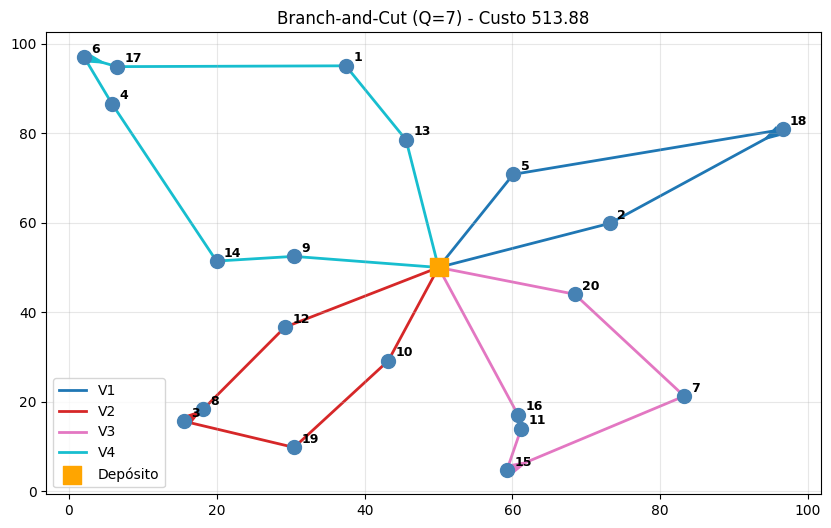


=== PARTE 2: BRANCH-AND-PRICE ===
--- B&P Iniciado (CVRP Q=7) ---
    Coluna heurística: {(0, 7), (7, 16), (16, 0)}, valor: 101.49570599120409
    Coluna heurística: {(0, 7), (7, 16), (16, 11), (11, 0)}, valor: 107.71608606581276
    Coluna heurística: {(0, 7), (15, 11), (16, 0), (11, 16), (7, 15)}, valor: 120.43599386262764
    Coluna heurística: {(0, 7), (7, 16), (19, 0), (11, 15), (15, 19), (16, 11)}, valor: 153.4339145422117
    Coluna heurística: {(0, 7), (19, 8), (7, 16), (8, 0), (11, 15), (15, 19), (16, 11)}, valor: 168.56857560994047
    Coluna heurística: {(0, 18), (2, 0), (18, 2)}, valor: 112.45704058442917
    Coluna heurística: {(0, 18), (2, 5), (5, 0), (18, 2)}, valor: 127.43997793831652
    Coluna heurística: {(13, 0), (5, 13), (18, 2), (0, 18), (2, 5)}, valor: 149.586397793909
    Coluna heurística: {(13, 1), (5, 13), (1, 0), (18, 2), (0, 18), (2, 5)}, valor: 185.97007809502458
    Coluna heurística: {(13, 1), (17, 0), (5, 13), (1, 17), (18, 2), (0, 18), (2, 5)}, valor:

    !!! Coluna exata: {(9, 0), (5, 1), (1, 4), (0, 2), (14, 9), (2, 18), (4, 14), (18, 5)}, valor: 228.54451283638272
    Coluna heurística: {(1, 0), (6, 1), (9, 6), (0, 9)}, valor: 154.74904265642775
    Coluna heurística: {(1, 18), (6, 1), (9, 6), (18, 0), (0, 9)}, valor: 224.61237251345852


    !!! Coluna exata: {(1, 5), (6, 1), (0, 9), (2, 0), (14, 6), (9, 14), (18, 2), (5, 18)}, valor: 242.26164872485657
    Coluna heurística: {(14, 8), (0, 9), (19, 0), (3, 19), (8, 3), (9, 14)}, valor: 127.82643314473731
    Coluna heurística: {(14, 8), (19, 7), (7, 0), (0, 9), (3, 19), (8, 3), (9, 14)}, valor: 181.07639790666812
    Coluna heurística: {(19, 7), (7, 0), (8, 3), (3, 19), (14, 9), (9, 8), (0, 14)}, valor: 194.5438430231503
    Coluna heurística: {(0, 2), (7, 0), (18, 7), (2, 18)}, valor: 161.6449429996887
    Coluna heurística: {(7, 0), (5, 18), (18, 7), (0, 5)}, valor: 165.97904874801657
    Coluna heurística: {(20, 7), (0, 20), (7, 0)}, valor: 90.51124399674089
    Coluna heurística: {(20, 7), (0, 20), (7, 18), (18, 0)}, valor: 163.47486005460877


In [ ]:
# EXECUÇÃO COMPARATIVA
print("=== PARTE 1: BRANCH-AND-CUT ===")
cost_bc, routes_bc = solve_branch_and_cut(inst, max_iters=50)
plot_routes(inst, routes_bc, f"Branch-and-Cut (Q={inst.Q}) - Custo {cost_bc:.2f}")

print("\n=== PARTE 2: BRANCH-AND-PRICE ===")
cost_bp, routes_bp = solve_full_branch_and_price(inst, time_limit=300)
plot_routes(inst, routes_bp, f"Branch-and-Price (Q={inst.Q}) - Custo {cost_bp:.2f}")

print(f"\nResumo Final:\nB&C: {cost_bc:.2f}\nB&P: {cost_bp:.2f}")